In [1]:
from typing import TypedDict, Dict, Callable, Literal, List, NotRequired

from langgraph.graph import StateGraph, START

In [2]:
OperatorType = Literal["+", "*"]

In [3]:
OPERATORS: Dict[OperatorType, Callable[[int, int], int]] = {
    "*": lambda a, b: a * b,
    "+": lambda a, b: a + b
}

In [4]:
class AgentState(TypedDict):
    number: NotRequired[int]
    tries: List[int]
    

In [5]:
import random
def random_num_gen(state: AgentState) -> AgentState:
    """Generate a random number

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    number = random.randint(1,3)
    state["number"] = number
    state["tries"].append(number)
    return state


def decide_next_node(state: AgentState) -> Literal["__end__", "generator"]:
    """decides which node on the graph to take"""
    
    if state and state.get('number') == 2:
        return "__end__"
    else:
        return "generator"
#obviously it'd be best to use a literal if you have multiple cases for type safety. also don't just use else, better to raise an error, but that's not my concern for now

#I stand corrected, it's imperative to use Literal because langgraph wont know the types at build time unless it's explicitly stated and str is kind of unbounded (especially when i dont plan on stating the mapping of nodes for the conditional edges <see cell 22, down there, line 7>)


In [6]:
graph = StateGraph(AgentState)
graph.add_node("generator", random_num_gen)
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")
graph.add_conditional_edges("router", decide_next_node)
graph.add_edge("generator", "router")

app = graph.compile()


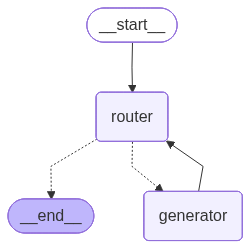

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
result1 = app.invoke({"tries": list()})

result1

{'number': 2, 'tries': [2]}